# Next token probability

## 1. Notebook set-up

### 1.1. Imports

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F

from transformers import AutoModelForCausalLM, AutoTokenizer

### 1.2. Configuration

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
temp = 0.7

model = 'openai-community/gpt2-large'
message = 'A turtle and a bird were walking in the forest one day. The turtle said, "'

### 1.3. Tokenizer

In [3]:
tokenizer = AutoTokenizer.from_pretrained(model)

print(f'Unknown token: {tokenizer.unk_token}')
print(f'Beginning of sequence token: {tokenizer.bos_token}')
print(f'End of sequence token: {tokenizer.eos_token}')

Unknown token: <|endoftext|>
Beginning of sequence token: <|endoftext|>
End of sequence token: <|endoftext|>


### 1.4. Model

In [4]:
model = AutoModelForCausalLM.from_pretrained(model)

## 2. Next token probability distribution

### 2.1. Tokenize the message

In [5]:
message = tokenizer.bos_token + message

inputs = tokenizer(message, return_tensors='pt')
print(f'Tokenized input shape: {inputs.input_ids.shape}')

Tokenized input shape: torch.Size([1, 19])


### 2.2. Run the pass

In [6]:
# Run single forward pass with gradient accumulation turned off
with torch.no_grad():
    outputs = model(**inputs)

# Interrogate the output object
print(f'Output type: {type(outputs)}')

Output type: <class 'transformers.modeling_outputs.CausalLMOutputWithCrossAttentions'>


Output is an instance of `CausalLMOutputWithCrossAttentions` see [here](CausalLMOutputWithCrossAttentions).

In [7]:
# Get the logits from the output object
logits = outputs.logits
print(f'Logits shape: {logits.shape}')

Logits shape: torch.Size([1, 19, 50257])


### 2.3. Recover probability distribution over the next token

In [ ]:
# Get the logits for the last token and sort them in descending order
logits, indices = logits[0, -1, :].sort(descending=True)

# Convert from float32 (single precision) to float64 (double precision)
logits = logits.double()

# Apply softmax to get probabilities
probs = F.softmax(logits, dim=0)

print(f'Probabilities shape: {probs.shape}')

Probabilities shape: torch.Size([50257])


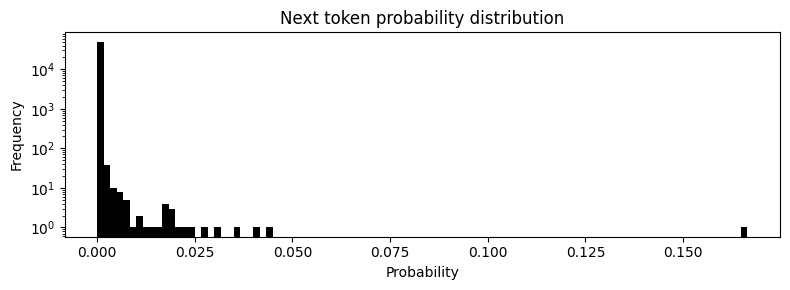

In [9]:
plt.figure(figsize=(8, 3))
plt.title('Next token probability distribution')
plt.hist(probs.numpy(), bins=100, color='black')
plt.yscale('log')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 2.4. Greedy decoding

In [14]:
top_k = 5

top_k_tokens = pd.DataFrame({
    'token': [tokenizer.decode(indices[i].item()) for i in range(top_k)],
    'probability': [probs[i].item() for i in range(top_k)]
})

top_k_tokens.head(top_k)

,token,probability
0,I,0.166489
1,Hey,0.044827
2,What,0.040215
3,Look,0.036289
4,Why,0.031234


## 3. Top k partitioning

### 3.1. Partition function

In [11]:
def partition_top_k(probs, indices, top_k, n_partitions):
    '''
    Partition the top_k tokens into n_partitions bins with approximately
    equal probability mass, using a greedy assignment.

    Returns a list of n_partitions lists, each containing (token_id, prob) pairs.
    '''

    # Get the top_k probabilities and their corresponding token indices
    top_probs = probs[:top_k]
    top_indices = indices[:top_k]

    # Create empty partitions and track their total mass
    partitions = [[] for _ in range(n_partitions)]
    partition_mass = [0.0] * n_partitions

    # Loop on the top_k tokens in descending order of probability
    for token_id, prob in zip(top_indices.tolist(), top_probs.tolist()):

        # Assign to the partition with the lowest current mass
        target = partition_mass.index(min(partition_mass))
        partitions[target].append((token_id, prob))
        partition_mass[target] += prob

    return partitions

### 3.2. Example partition

In [16]:
# Partition top 20 tokens into 2 bins
partitions = partition_top_k(probs, indices, top_k=20, n_partitions=2)

# Print the partitions and their total mass
for i, part in enumerate(partitions):

    tokens = [f'"{tokenizer.decode(tid)}" ({p:.4f})' for tid, p in part]
    mass = sum(p for _, p in part)
    print(f'Partition {i} (mass={mass:.4f}): {", ".join(tokens)}\n')

Partition 0 (mass=0.2942): "I" (0.1665), "This" (0.0239), "There" (0.0208), "We" (0.0190), "Oh" (0.0182), "Where" (0.0175), "Hello" (0.0160), "If" (0.0124)

Partition 1 (mass=0.3001): "Hey" (0.0448), "What" (0.0402), "Look" (0.0363), "Why" (0.0312), "You" (0.0270), "My" (0.0228), "Come" (0.0195), "Let" (0.0188), "It" (0.0178), "How" (0.0173), "The" (0.0137), "Do" (0.0107)

